 1) What are Type I and Type II errors in hypothesis testing, and how do they
impact decision-making?

In hypothesis testing, a Type I error (α) occurs when the null hypothesis (H₀) is true but is incorrectly rejected. It represents a false positive. For example, concluding a treatment works when it actually does not. A Type II error (β) occurs when the null hypothesis is false but is incorrectly accepted—this is a false negative, such as failing to detect a real effect. These errors influence decision-making by balancing risk: reducing Type I error typically increases Type II error and vice versa. Researchers choose acceptable error levels depending on the consequences (e.g., medical trials prioritize minimizing Type I errors).

2. What is the P-value in hypothesis testing, and how should it be interpreted
in the context of the null hypothesis?

The P-value is the probability of observing the sample statistic—or something more extreme—assuming the null hypothesis (H₀) is true. A small P-value (usually < 0.05) indicates strong evidence against H₀, leading to its rejection. A large P-value suggests the data are consistent with H₀, so we fail to reject it. Importantly, a P-value does not measure the probability that H₀ is true or false; it only measures how incompatible the observed data are with H₀.

3. Explain the difference between a Z-test and a T-test, including when to use
each.

A Z-test is used when the population standard deviation (σ) is known and the sample size is large (typically n > 30). It assumes normality of the sampling distribution. A T-test, on the other hand, is used when σ is unknown and must be estimated from the sample. It is appropriate for smaller samples (n ≤ 30) and uses the t-distribution, which has heavier tails. As n increases, the t-distribution approximates the normal distribution, making the tests similar.

4. What is a confidence interval, and how does the margin of error influence
its width and interpretation?

A confidence interval (CI) is a range of values that likely contains the true population parameter with a specified confidence level (e.g., 95%). The margin of error (ME) determines how wide the interval is. A larger ME (due to small sample size, high variability, or high confidence level) results in a wider CI, meaning less precision. A smaller ME produces a narrower CI, providing a more precise estimate of the parameter.

5. Describe the purpose and assumptions of an ANOVA test. How does it
extend hypothesis testing to more than two groups?

The Analysis of Variance (ANOVA) test is a statistical test used to determine whether there are any statistically significant differences between the means of three or more independent (unrelated) groups.

Purpose

The primary purpose of an ANOVA test is to compare the means of multiple groups simultaneously to see if at least one group mean is different from the others. It does this by comparing the variance between the groups to the variance within the groups.

Assumptions

Independence: The samples are independent (i.e., measurements in one group do not influence the measurements in another).

Normality: The populations from which the samples are drawn are approximately normally distributed.

Homogeneity of Variance (Homoscedasticity): The variances of the populations from which the samples are drawn are equal.

Extension to More Than Two Groups

-A Z-test or T-test is used to compare the means of only two groups.
-If you had three or more groups (e.g., Group A, B, and C), using multiple two-sample T-tests (A vs. B, A vs. C, B vs. C) would inflate the overall Type I error rate ($\alpha$). The chance of getting a false positive increases with each additional test.
-ANOVA controls this overall Type I error rate by performing a single, omnibus test17. The null hypothesis for a one-way ANOVA is $H_0: \mu_1 = \mu_2 = \dots = \mu_k$, where $k$ is the number of groups. If the ANOVA test is significant, it indicates that at least one group mean is different, without specifying which one(s). Post-hoc tests (like Tukey's HSD) are then used to find the specific pairs of groups that differ.




6. Write a Python program to perform a one-sample Z-test and interpret the
result for a given dataset.

In [1]:
import numpy as np
from scipy.stats import norm

# sample dataset
data = np.array([12, 15, 14, 16, 13, 15, 14])
mu0 = 14     # hypothesized population mean
sigma = 2    # known population standard deviation

# Z-test calculation
sample_mean = np.mean(data)
n = len(data)
z_stat = (sample_mean - mu0) / (sigma / np.sqrt(n))

# p-value (two-tailed)
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print("Z-statistic:", z_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")


Z-statistic: 0.18898223650461296
P-value: 0.8501067391385264
Fail to reject the null hypothesis.


7. Simulate a dataset from a binomial distribution (n = 10, p = 0.5) using
NumPy and plot the histogram.

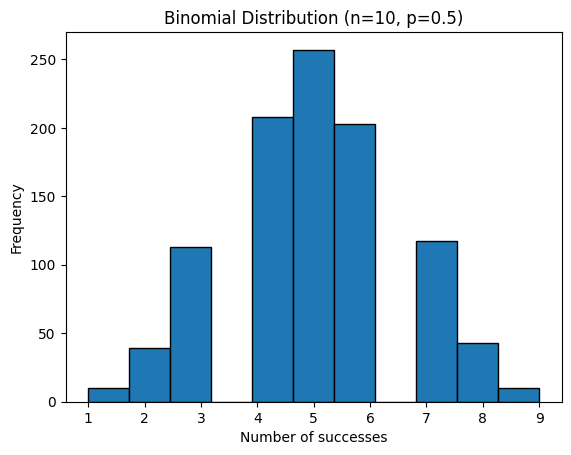

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# simulate data
data = np.random.binomial(n=10, p=0.5, size=1000)

# plot histogram
plt.hist(data, bins=11, edgecolor='black')
plt.xlabel("Number of successes")
plt.ylabel("Frequency")
plt.title("Binomial Distribution (n=10, p=0.5)")
plt.show()


8. Generate multiple samples from a non-normal distribution and implement
the Central Limit Theorem using Python.

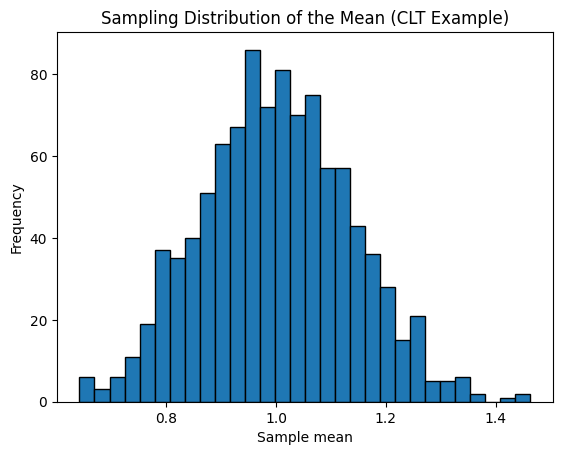

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# generate exponential (non-normal) distribution
samples = [np.mean(np.random.exponential(scale=1, size=50)) for _ in range(1000)]

plt.hist(samples, bins=30, edgecolor='black')
plt.title("Sampling Distribution of the Mean (CLT Example)")
plt.xlabel("Sample mean")
plt.ylabel("Frequency")
plt.show()


9. Write a Python function to calculate and visualize the confidence interval
for a sample mean.

95.0% CI: (-0.32709029027565434, 0.4375225047309201)


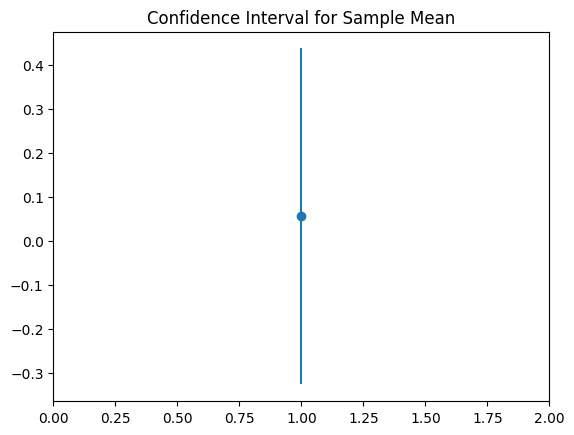

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

def plot_confidence_interval(data, confidence=0.95):
    mean = np.mean(data)
    n = len(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    t_crit = t.ppf((1 + confidence) / 2, df=n-1)

    lower = mean - t_crit * se
    upper = mean + t_crit * se

    print(f"{confidence*100}% CI: ({lower}, {upper})")

    plt.errorbar(1, mean, yerr=[[mean - lower], [upper - mean]], fmt='o')
    plt.xlim(0, 2)
    plt.title("Confidence Interval for Sample Mean")
    plt.show()

# example use:
data = np.random.randn(30)
plot_confidence_interval(data)


10. Perform a Chi-square goodness-of-fit test using Python to compare
observed and expected distributions, and explain the outcome.

In [5]:
import numpy as np
from scipy.stats import chisquare

observed = np.array([25, 30, 20, 25])
expected = np.array([25, 25, 25, 25])

chi_stat, p_value = chisquare(observed, expected)

print("Chi-square statistic:", chi_stat)
print("P-value:", p_value)


Chi-square statistic: 2.0
P-value: 0.5724067044708798


Explanation:

If P-value < 0.05, the observed frequencies differ significantly from expected frequencies.

If P-value ≥ 0.05, there is no statistically significant difference between observed and expected distributions.